In [ ]:
#Cargamos librerías
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sp_signal
from scipy.signal import iirnotch, butter, filtfilt, medfilt
from scipy.signal import firwin, lfilter
from numpy.fft import fft, fftfreq
from scipy.signal import correlate

!pip install neurokit2
import neurokit2 as nk
from scipy.signal import resample

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

####Ejercicio 1
##### Filtro pasabanda: Un laboratorio de ingeniería biomédica desarrolla un monitor ECG portátil. Las señales presentan múltiples componentes frecuenciales y se requiere aislar únicamente la banda cardíaca relevante.

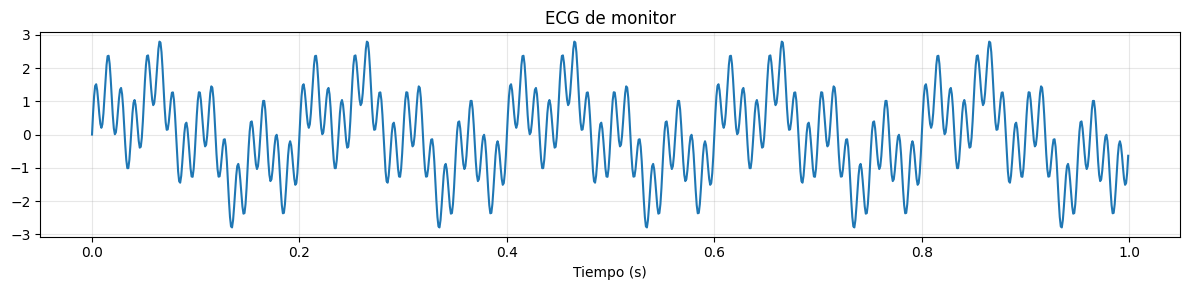

In [ ]:
#Genere tres señales:5 Hz, 20 Hz, 80 Hz
#Diseñe un filtro pasa banda que permita únicamente:15 Hz a 30 Hz. Presente: Señal temporal y FFT antes/después

#Generar las señales
fs = 1000 # Hz
t  = np.arange(0, 1, 1/fs) # 1 segundo
s1 = np.sin(2 * np.pi * 5  * t) #5 Hz
s2 = np.sin(2 * np.pi * 20 * t) #20 Hz
s3 = np.sin(2 * np.pi * 80 * t) #80 Hz

signal = s1 + s2 + s3 # señal combinada

plt.figure(figsize=(12, 3))
plt.plot(t, signal)
plt.title('ECG de monitor')
plt.xlabel('Tiempo (s)');
plt.tight_layout(); plt.show()


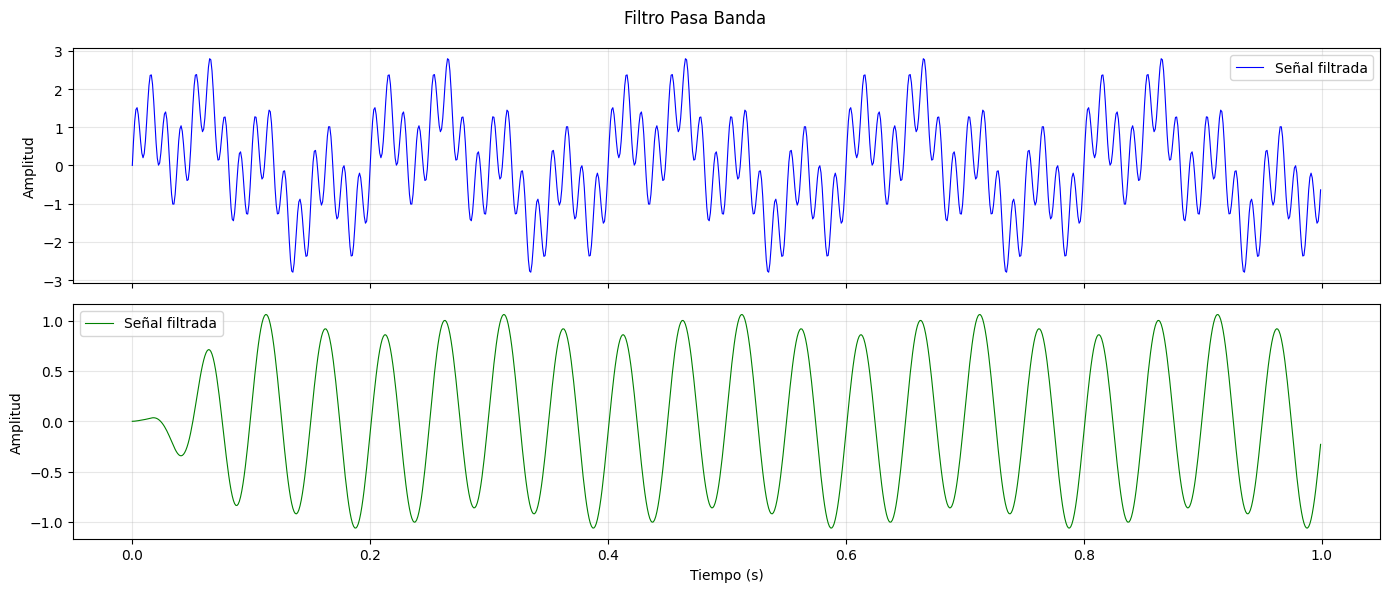

In [ ]:
#Filtrando las señales
N = 101 # orden del filtro
fir = firwin(N, [15, 30], pass_zero=False, fs=fs)
filtered = lfilter(fir, 1.0, signal)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(t, signal,   color='blue',  linewidth=0.8, label='Señal filtrada')
axes[1].plot(t, filtered, color='green', linewidth=0.8, label='Señal filtrada')
for ax in axes:
    ax.legend(); ax.set_ylabel('Amplitud')
axes[1].set_xlabel('Tiempo (s)')
plt.suptitle('Filtro Pasa Banda')
plt.tight_layout()
plt.show()

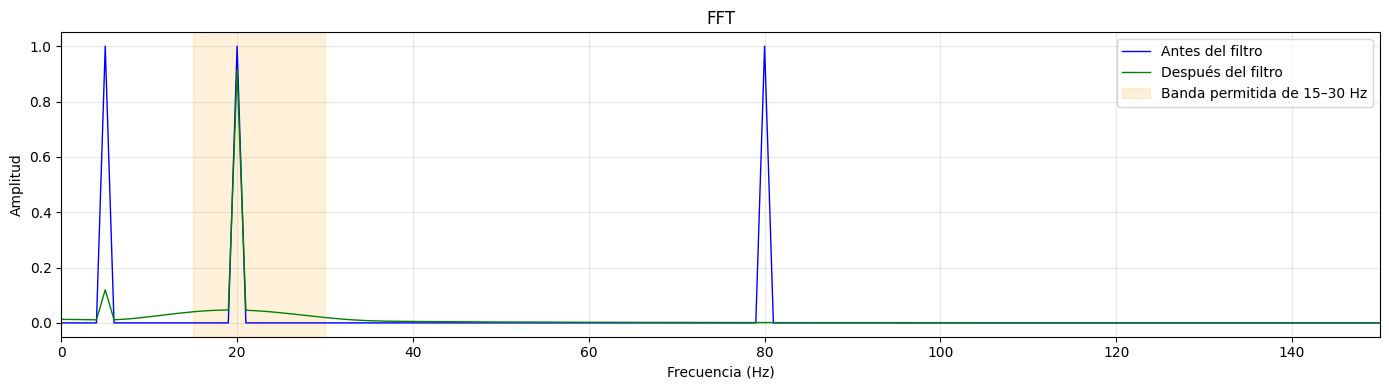

In [ ]:
#Ahora mostramos la FFT de las señales
def plot_fft(sig, fs, label, color, ax):
    N = len(sig)
    f = fftfreq(N, 1/fs)[:N//2]
    Y = (2/N) * np.abs(fft(sig))[:N//2]
    ax.plot(f, Y, color=color, label=label, linewidth=1)

fig2, ax = plt.subplots(figsize=(14, 4))
plot_fft(signal, fs,'Antes del filtro','blue',ax)
plot_fft(filtered, fs,'Después del filtro', 'green', ax)
ax.axvspan(15, 30, alpha=0.15, color='orange', label='Banda permitida de 15–30 Hz')
ax.set_xlim(0, 150)
ax.set_xlabel('Frecuencia (Hz)'); ax.set_ylabel('Amplitud')
ax.set_title('FFT')
ax.legend()
plt.tight_layout()
plt.show()


####Ejercicio 2
##### Eliminación de ruido blanco: Un sistema de telemedicina transmite señales ECG desde zonas rurales.Las señales presentan ruido blanco debido al sistema electrónico y transmisión inalámbrica.

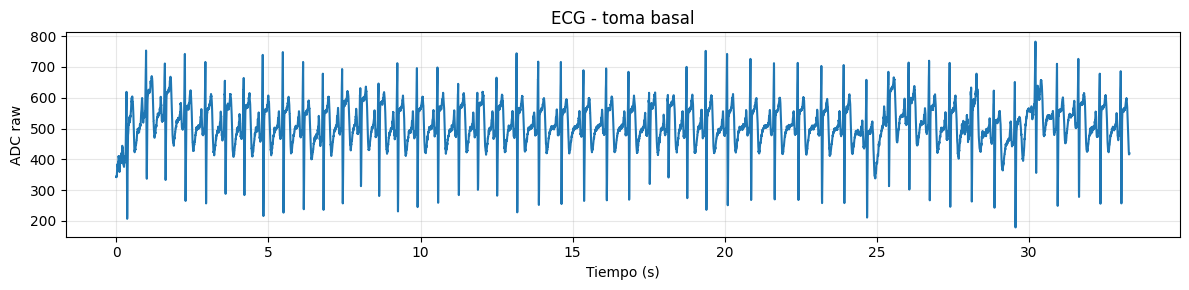

In [ ]:
#Vamos a reutilizar la señal ECG del laboratorio
data = np.loadtxt('basal1_III.txt', comments='#')
ecg = data[:, -1] #tomamos columna A2 = ECG (última columna)
fs = 1000  # Hz
t = np.arange(len(ecg)) / fs

plt.figure(figsize=(12, 3))
plt.plot(t, ecg)
plt.title('ECG - toma basal')
plt.xlabel('Tiempo (s)'); plt.ylabel('ADC raw')
plt.tight_layout(); plt.show()

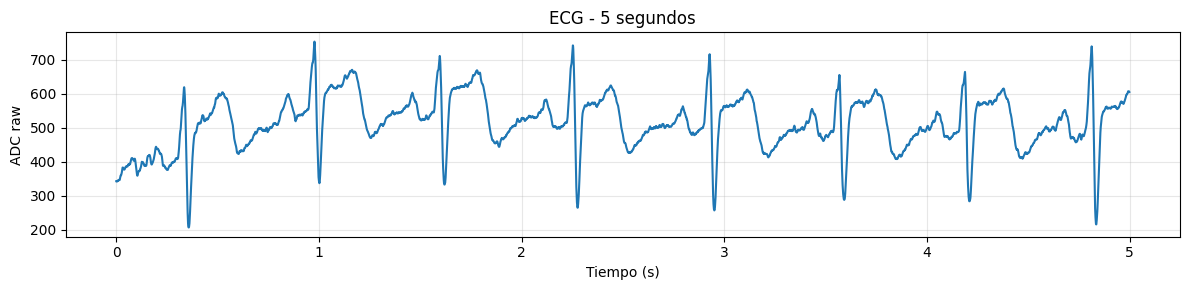

In [ ]:
#Tomamos solo los primeros 5 segundos
seg = 5
muestras = seg * fs
ecg_base = ecg[:muestras].astype(float)
t = np.arange(muestras) / fs

plt.figure(figsize=(12, 3))
plt.plot(t, ecg_base)
plt.title('ECG - 5 segundos')
plt.xlabel('Tiempo (s)'); plt.ylabel('ADC raw')
plt.tight_layout(); plt.show()

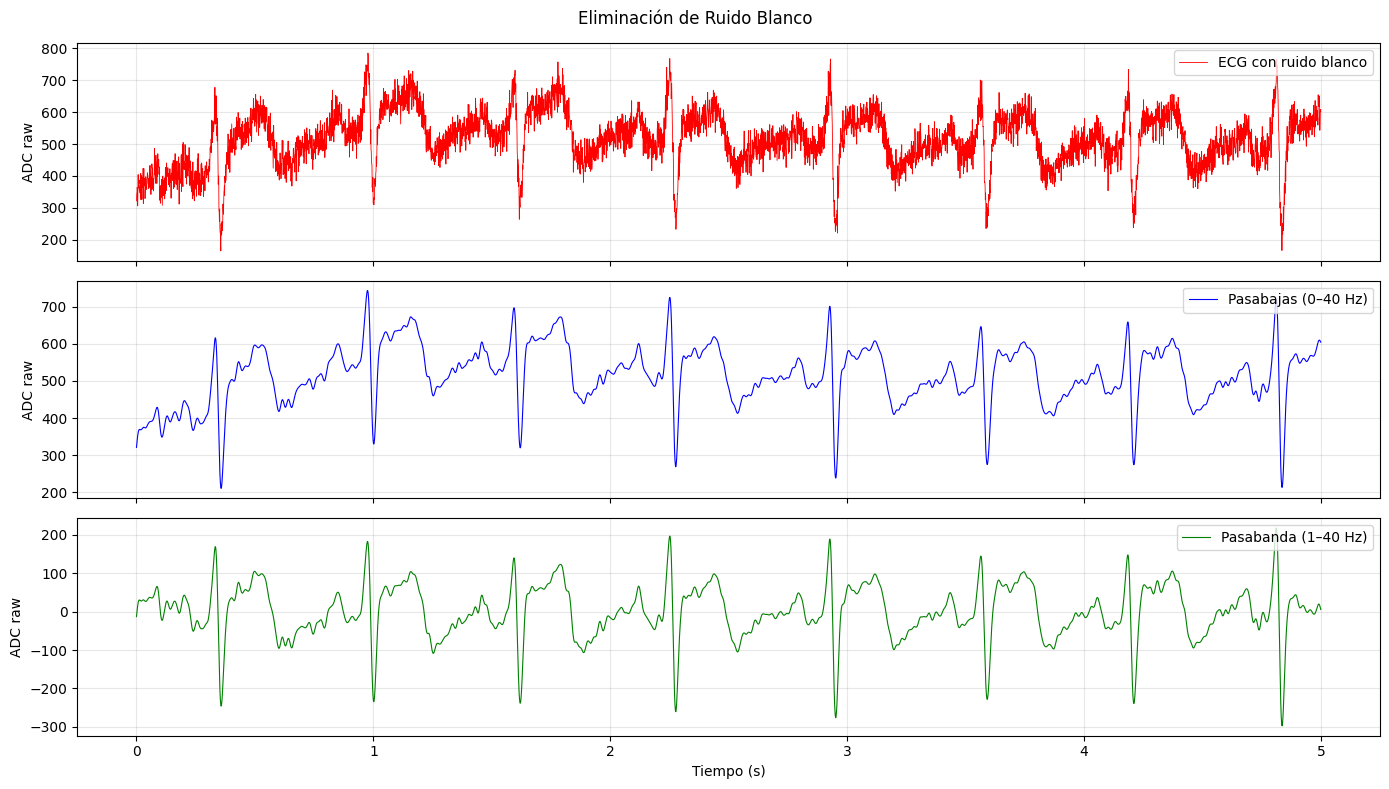

In [ ]:
#le agregamos ruido a la señal
noisy = ecg_base + 30 * np.random.randn(muestras)  # ruido blanco
#Creamos el filtro lowwpass
b, a = butter(4, 40, btype='low', fs=fs)
filtered_low = filtfilt(b, a, noisy)
#Filtro pasabanda
b, a = butter(4, [1, 40], btype='band', fs=fs)
filtered_band = filtfilt(b, a, noisy)
#Ahora graficamos
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(t, noisy,        color='red', linewidth=0.6,label='ECG con ruido blanco')
axes[1].plot(t, filtered_low, color='blue',linewidth=0.8,label='Pasabajas (0–40 Hz)')
axes[2].plot(t, filtered_band,color='green',linewidth=0.8,label='Pasabanda (1–40 Hz)')

for ax in axes:
    ax.legend(loc='upper right'); ax.set_ylabel('ADC raw')
axes[2].set_xlabel('Tiempo (s)')
plt.suptitle('Eliminación de Ruido Blanco')
plt.tight_layout()
plt.show()


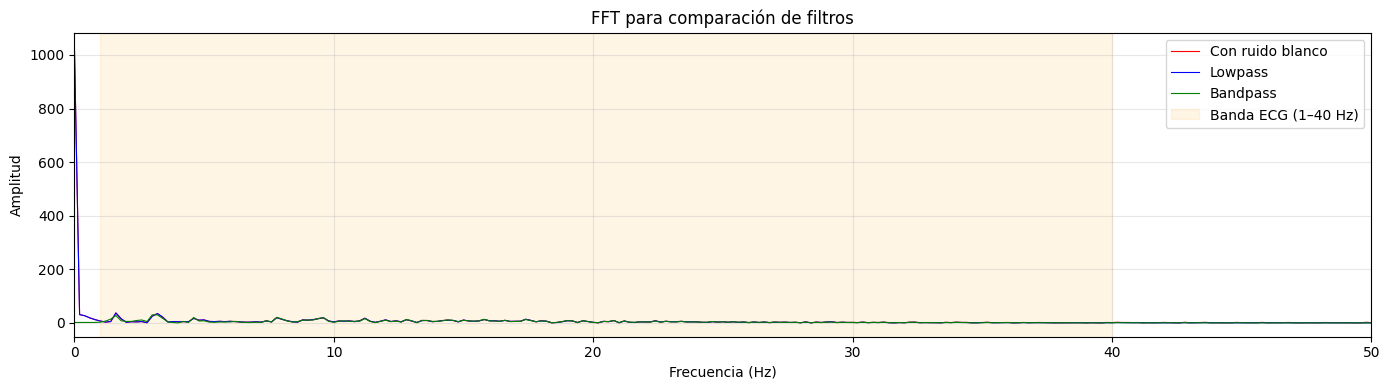

In [ ]:
#Graficamos FFT
def plot_fft(sig, fs, label, color, ax):
    N = len(sig)
    f = fftfreq(N, 1/fs)[:N//2]
    Y = (2/N) * np.abs(fft(sig))[:N//2]
    ax.plot(f, Y, color=color, label=label, linewidth=0.8)

fig2, ax = plt.subplots(figsize=(14, 4))
plot_fft(noisy, fs, 'Con ruido blanco', 'red',   ax)
plot_fft(filtered_low, fs, 'Lowpass','blue',  ax)
plot_fft(filtered_band,fs, 'Bandpass', 'green', ax)
ax.axvspan(1, 40, alpha=0.1, color='orange', label='Banda ECG (1–40 Hz)')
ax.set_xlim(0, 50) #para mejor visualización
ax.set_xlabel('Frecuencia (Hz)'); ax.set_ylabel('Amplitud')
ax.set_title('FFT para comparación de filtros')
ax.legend()
plt.tight_layout()
plt.show()

####Ejercicio 3
##### Ruido impulsivo: Durante un registro EEG aparecen desconexiones instantáneas de electrodos produciendo spikes abruptos.

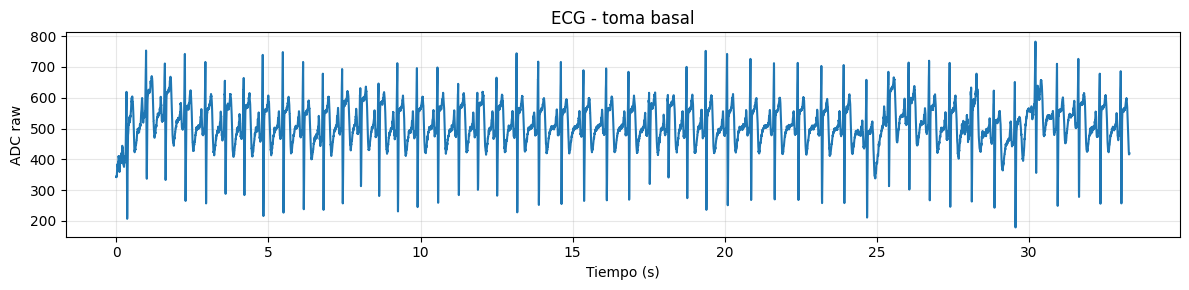

In [ ]:
#Usaremos señal cargada del laboratorio
#cargamos la señal
data = np.loadtxt('basal1_III.txt', comments='#')
ecg = data[:, -1] #tomamos columna A2 = ECG (última columna)
fs = 1000  # Hz
t = np.arange(len(ecg)) / fs

plt.figure(figsize=(12, 3))
plt.plot(t, ecg)
plt.title('ECG - toma basal')
plt.xlabel('Tiempo (s)'); plt.ylabel('ADC raw')
plt.tight_layout(); plt.show()


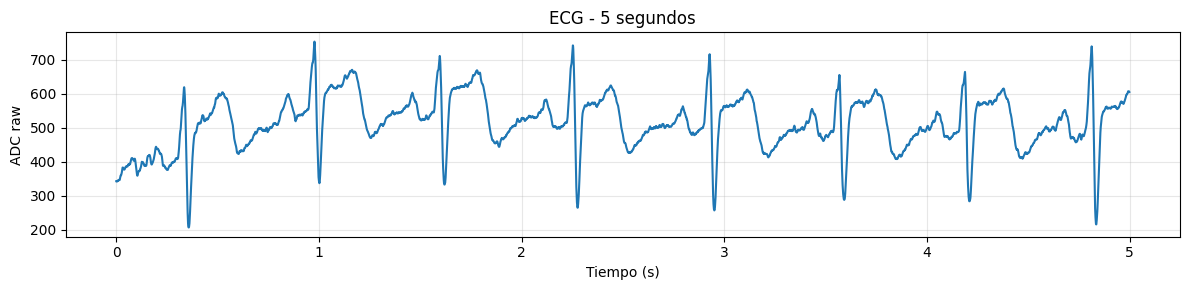

In [ ]:
#Delimitamos a solo 5 segundos para una mejor visualización
seg = 5
muestras = seg * fs
eeg = ecg[:muestras].astype(float) # reutilizamos la señal real
t   = np.arange(muestras) / fs
plt.figure(figsize=(12, 3))
plt.plot(t, eeg)
plt.title('ECG - 5 segundos')
plt.xlabel('Tiempo (s)'); plt.ylabel('ADC raw')
plt.tight_layout(); plt.show()

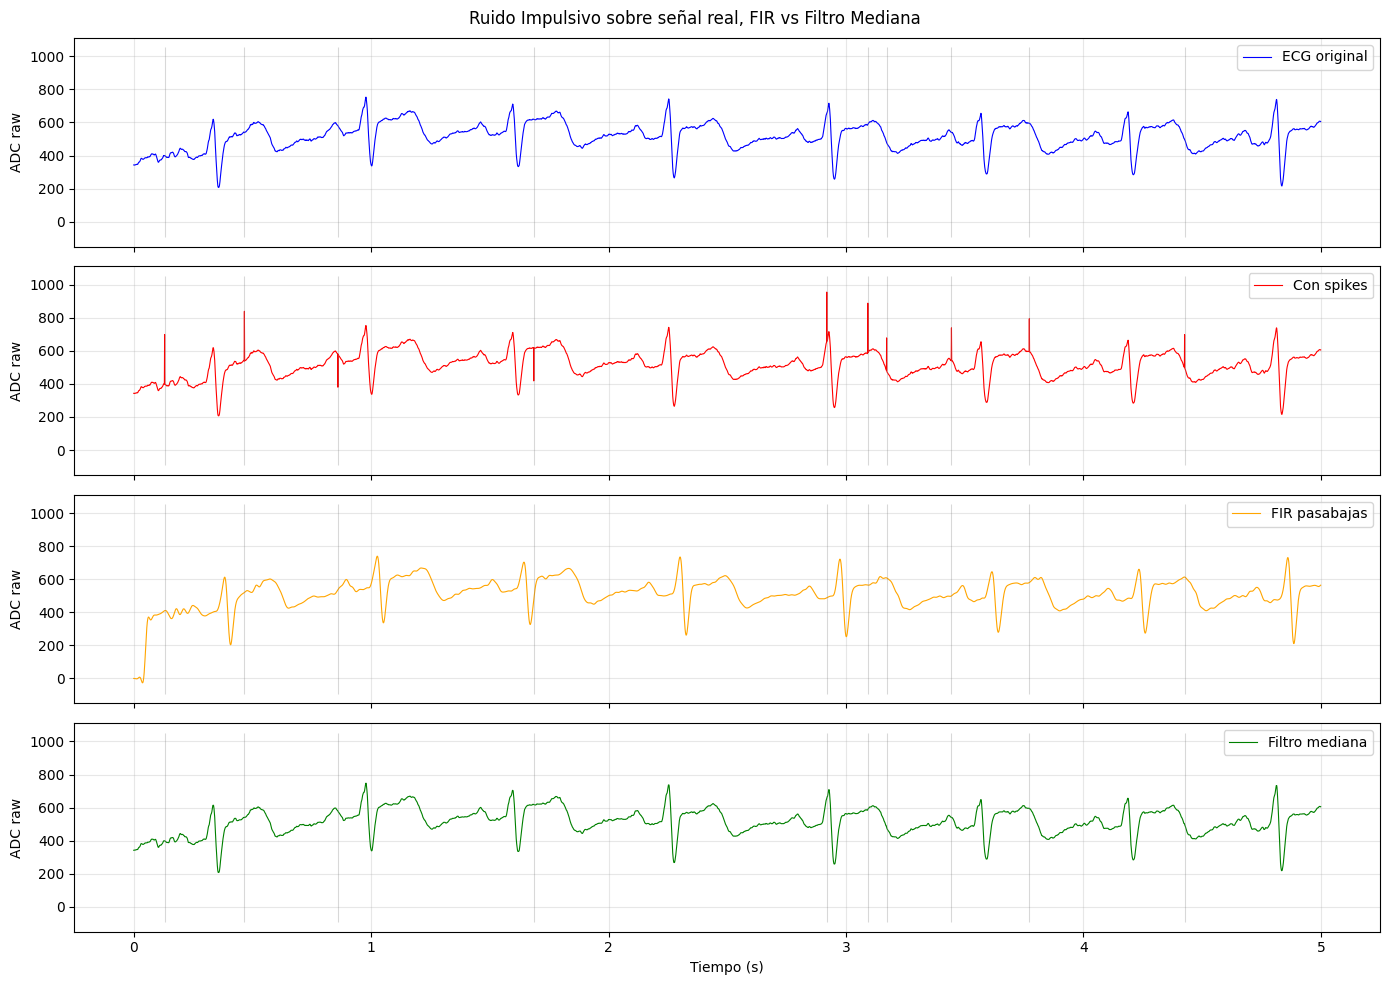

In [ ]:
#Agregamos spikes aleatorios
np.random.seed(42)
spike_idx = np.random.randint(0, muestras, 10)
eeg_noisy = eeg.copy()
for idx in spike_idx:
    eeg_noisy[idx] = np.random.choice([-200, 200, -300, 300]) + eeg[idx]
#Creamos filtro pasabajos
fir = firwin(101, 40, fs=fs)
eeg_fir = lfilter(fir, 1.0, eeg_noisy)

#Ahora filtro mediana
eeg_median = medfilt(eeg_noisy, 5)

#graficamos resultados
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(t,eeg, color='blue',linewidth=0.8, label='ECG original')
axes[1].plot(t,eeg_noisy, color='red',linewidth=0.8,label='Con spikes')
axes[2].plot(t,eeg_fir, color='orange',linewidth=0.8,label='FIR pasabajas')
axes[3].plot(t,eeg_median,color='green',linewidth=0.8,label='Filtro mediana')

for ax in axes:
    ax.vlines(t[spike_idx], eeg.min()-300, eeg.max()+300,
              color='gray', alpha=0.3, linewidth=0.8)
    ax.legend(loc='upper right'); ax.set_ylabel('ADC raw')

axes[3].set_xlabel('Tiempo (s)')
plt.suptitle('Ruido Impulsivo sobre señal real, FIR vs Filtro Mediana')
plt.tight_layout()
plt.show()

####Ejercicio 4
#####Un monitor ECG hospitalario presenta interferencia causada por la red eléctrica (60Hz)

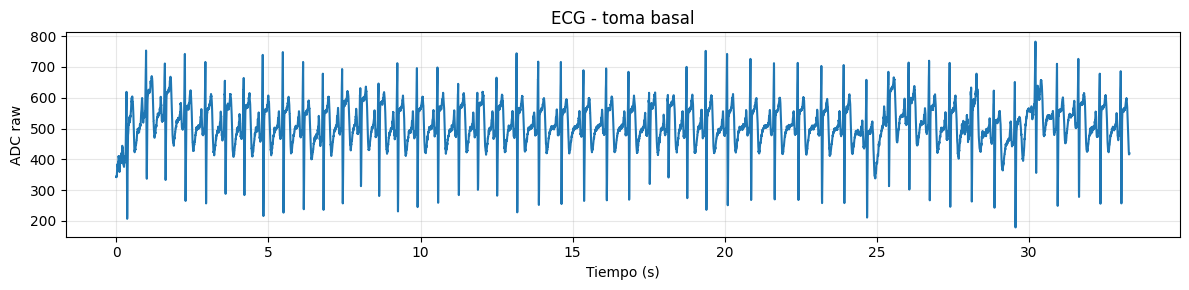

In [ ]:
#Señal y ruido blanco
#En este caso vamos a usar una señal ECG tomada del laboratorio
#Usaremos una toma basal para asegurarnos de que sea lo más limpia posible al momento de añadir el ruido

#cargamos la señal
data = np.loadtxt('basal1_III.txt', comments='#')
ecg = data[:, -1] #tomamos columna A2 = ECG (última columna)
fs = 1000  # Hz
t = np.arange(len(ecg)) / fs

plt.figure(figsize=(12, 3))
plt.plot(t, ecg)
plt.title('ECG - toma basal')
plt.xlabel('Tiempo (s)'); plt.ylabel('ADC raw')
plt.tight_layout(); plt.show()


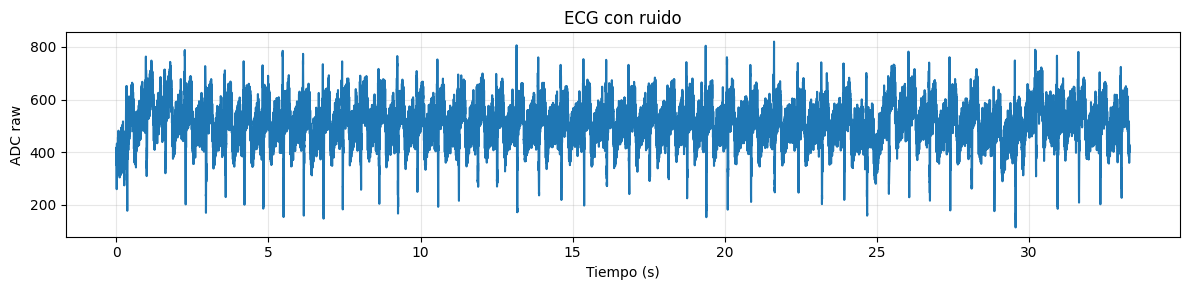

In [ ]:
#Agregando ruido
np.random.seed(42)
t = np.arange(len(ecg)) / fs

ruido  = 50  * np.sin(2 * np.pi * 60 * t) #interferencia eléctrica de 60 Hz
ruido_bl = 20  * np.random.randn(len(ecg)) #ruido blanco

ecg_ruidoso = ecg + ruido + ruido_bl

plt.figure(figsize=(12, 3))
plt.plot(t, ecg_ruidoso)
plt.title('ECG con ruido')
plt.xlabel('Tiempo (s)'); plt.ylabel('ADC raw')
plt.tight_layout(); plt.show()


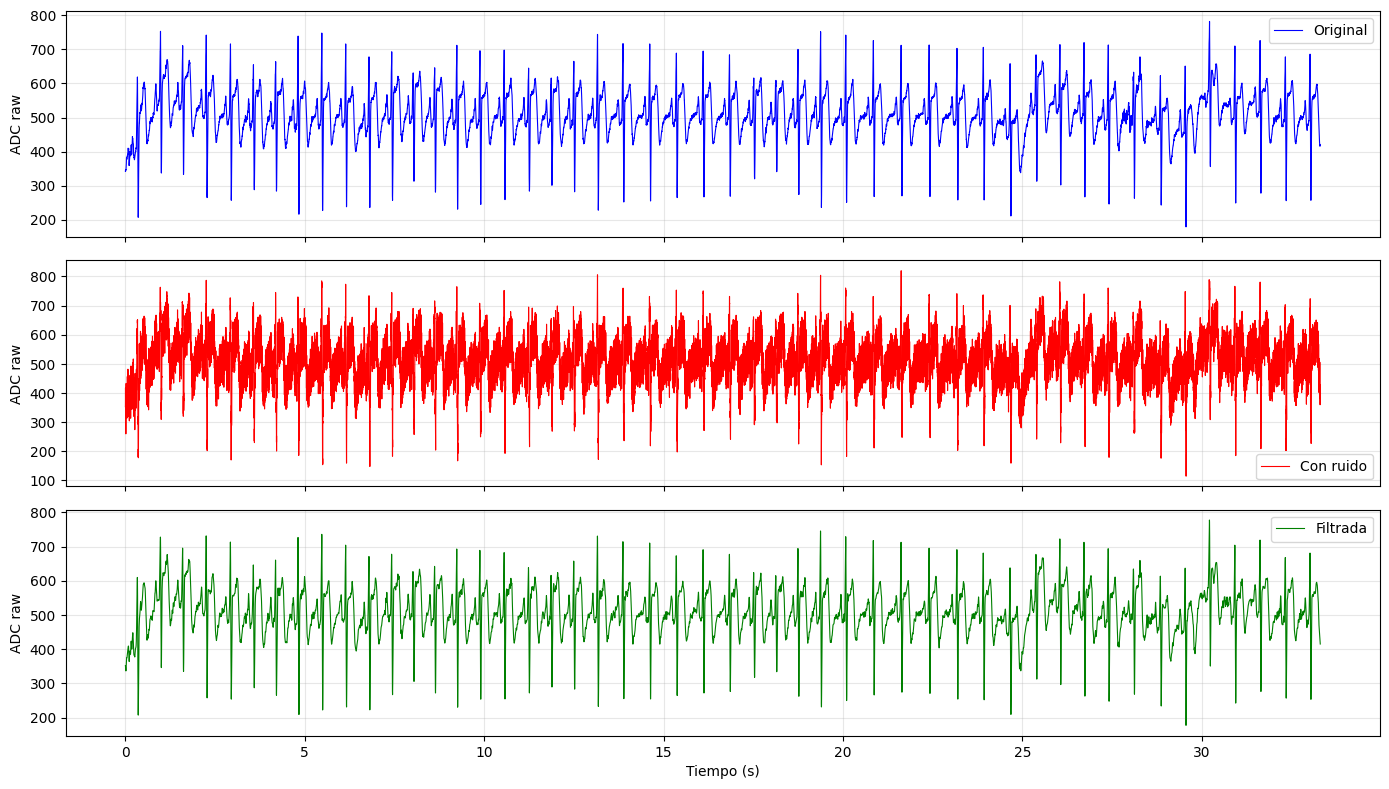

In [ ]:
#Ayuda para crear el filtro
b, a = iirnotch(60, 30, fs)
filtered = filtfilt(b, a, ecg_ruidoso)

#Ahora aplicamos un low pass para elimina el ruido blanco
b2, a2 = butter(4, 40, btype='low', fs=fs)
filtered = filtfilt(b2, a2, filtered)

#finalmente graficamos
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
axes[0].plot(t,ecg,color='blue',linewidth=0.8,label='Original')
axes[1].plot(t,ecg_ruidoso,color='red',linewidth=0.8,label='Con ruido')
axes[2].plot(t,filtered,color='green',linewidth=0.8,label='Filtrada')

for ax in axes:
    ax.legend(); ax.set_ylabel('ADC raw')
axes[2].set_xlabel('Tiempo (s)')
plt.tight_layout()
plt.show()


####Ejercicio 5
##### Sensores desincronizados: Un wearable biomédico utiliza: ECG respiración acelerómetro. Cada sensor inicia adquisición en tiempos distintos.


In [ ]:
# Simulación de señal
def acc_simulate(duration, fs):
    t = np.linspace(0, duration, duration * fs)

    signal = np.sin(2 * np.pi * 2 * t)
    noise = np.random.normal(0, 0.2, len(t))

    return signal + noise

# Añadimos el ruido
def add_delay_and_noise(signal, delay_s, fs, noise_level=0.05):
    delay_samples = int(delay_s * fs)

    delayed = np.roll(signal, delay_samples)
    noise = np.random.normal(0, noise_level, len(signal))

    return delayed + noise

# Usamos correlación
def align_signals(s1, s2):

    corr = correlate(s1, s2)
    estimated_delay = np.argmax(corr) - len(s1)

    print("Delay:", estimated_delay)

    aligned = np.roll(s2, -estimated_delay)
    return aligned, estimated_delay

# Creamos señal ECG
fs = 1000

ecg = nk.ecg_simulate(duration=10, sampling_rate=fs, heart_rate=80)
resp = nk.rsp_simulate(duration=10, sampling_rate=fs)
acc = acc_simulate(10, fs)
#añadimos delay y ruido
ecg_d = add_delay_and_noise(ecg, 2, fs)
resp_d = add_delay_and_noise(resp, 4, fs)
acc_d = add_delay_and_noise(acc, 6, fs)

# Align signals
resp_aligned, lag1 = align_signals(ecg_d, resp_d)
acc_aligned, lag2 = align_signals(ecg_d, acc_d)

Delay: -1439
Delay: 1085


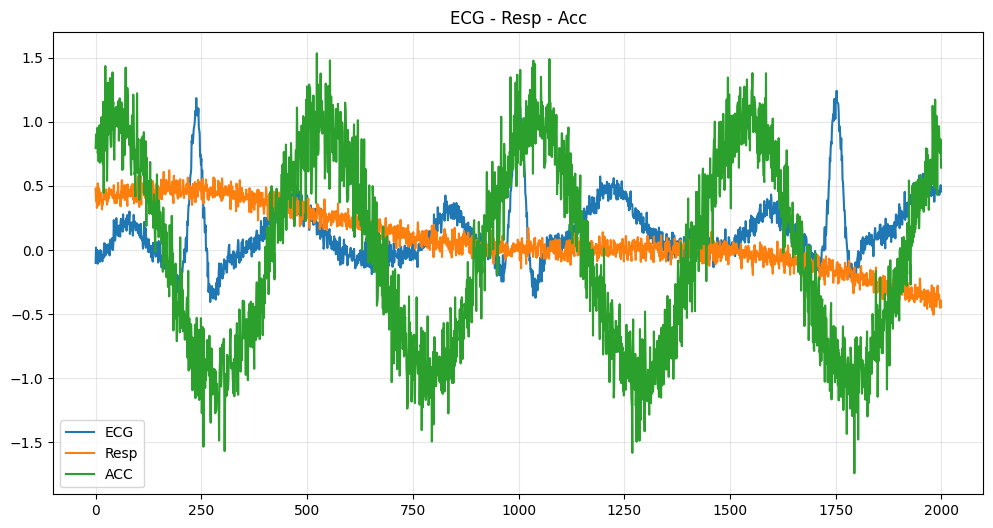

In [ ]:
# Ploteamos
plt.figure(figsize=(12,6))

plt.plot(ecg_d[:2000], label="ECG")
plt.plot(resp_aligned[:2000], label="Resp")
plt.plot(acc_aligned[:2000], label="ACC")

plt.legend()
plt.title("ECG - Resp - Acc")
plt.show()

####Ejercicio 6
##### Resampling multisensor: En una adquisición clínica: ECG se adquiere a 500Hz, respiración a 100Hz, temperatura a 200Hz. Se requiere fusionar todas las señales.

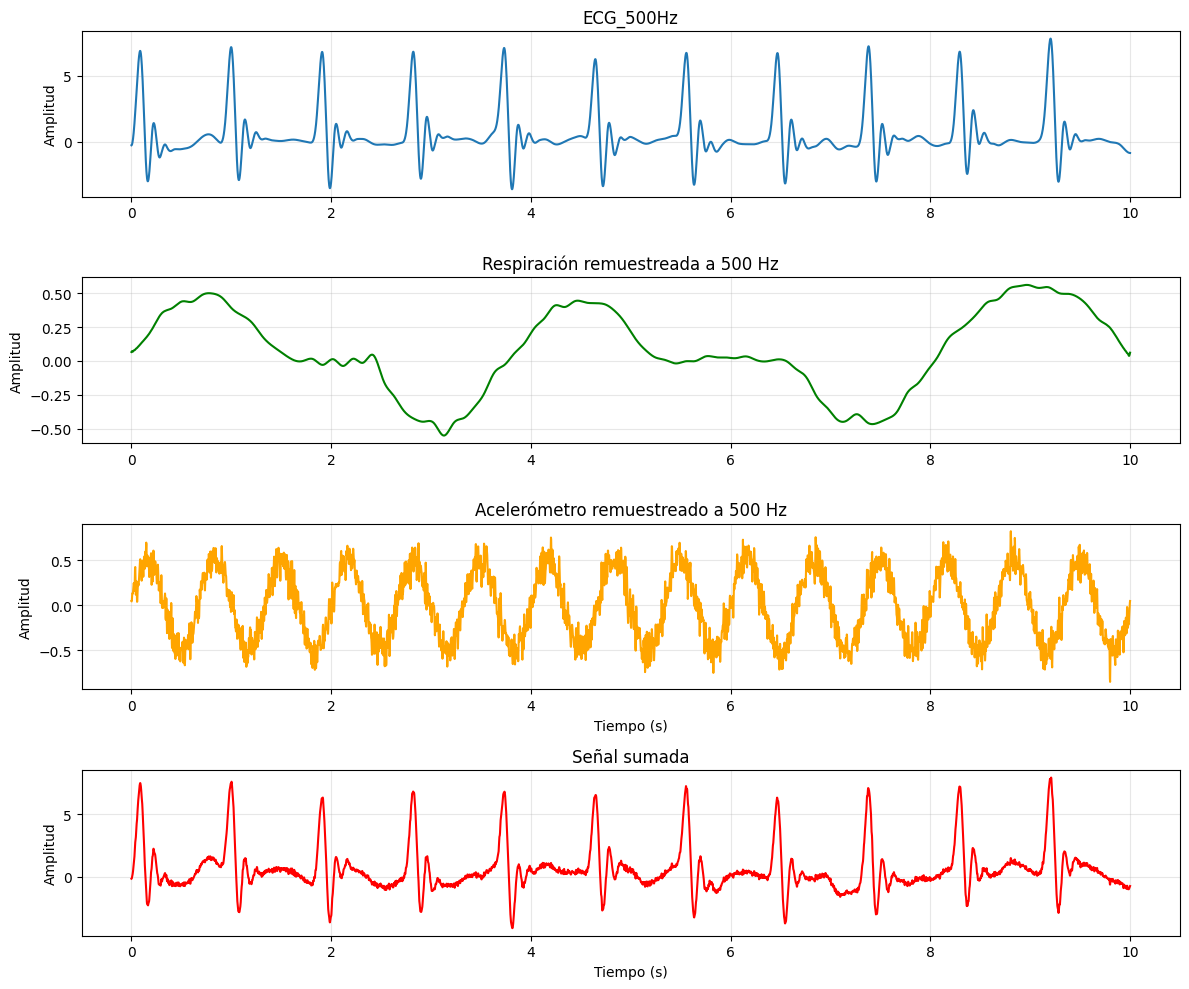

In [ ]:
#Creación de las señales
tiempoTotal = 10
S_ecg = nk.ecg_simulate(duration=tiempoTotal, sampling_rate=500, method="simple",noise=0.1)
S_rsp = nk.rsp_simulate(duration=tiempoTotal, sampling_rate=100, method="breathmetrics",noise=0.05)

t_acc = np.linspace(0, tiempoTotal, tiempoTotal*200)
S_acc = (0.5 * np.sin(2 * np.pi * 1.5 * t_acc) + 0.1*np.random.randn(len(t_acc)))

#Para el len uso el tiempo total multiplicado por la frecuencia y eso me da el tamaño total
rsp_resampled = resample(S_rsp, tiempoTotal*500)
acc_resampled = resample(S_acc, tiempoTotal*500)
t = np.linspace(0, tiempoTotal, tiempoTotal*500)

S_total = S_ecg + rsp_resampled + acc_resampled

#Graficamos todo
plt.figure(figsize=(12, 10))
plt.subplot(4,1,1)
plt.plot(t, S_ecg)
plt.title("ECG_500Hz")
plt.ylabel("Amplitud")
plt.grid(True)
plt.subplot(4,1,2)
plt.plot(t, rsp_resampled, color='green')
plt.title("Respiración remuestreada a 500 Hz")
plt.ylabel("Amplitud")
plt.grid(True)
plt.subplot(4,1,3)
plt.plot(t, acc_resampled, color='orange')
plt.title("Acelerómetro remuestreado a 500 Hz")
plt.ylabel("Amplitud")
plt.xlabel("Tiempo (s)")
plt.grid(True)
plt.subplot(4,1,4)
plt.plot(t, S_total, color='red')
plt.title("Señal sumada")
plt.ylabel("Amplitud")
plt.xlabel("Tiempo (s)")
plt.grid(True)
plt.tight_layout()
plt.show()